# 00 · 수식을 NumPy로 옮기기

**이번 질문:** $z_k=\sum_d x_d W_{dk}+b_k$라는 식을 보고, 배열의 모양과 코드를 직접 정할 수 있을까요?

수식의 기호를 한 번에 외우기보다 **숫자 두 개 → 샘플 여러 개 → 출력 여러 개**로 넓혀 보겠습니다.
각 단계에는 완성된 작은 예제와 검산이 있고, 마지막에는 직접 바꿔 보는 문제가 있습니다.

- 준비물: Python의 변수·함수·반복문을 읽을 수 있으면 시작할 수 있습니다. 배열 문법은 나오는 자리에서 설명합니다.
- 도착점: 내적, 행렬곱, 브로드캐스팅, 축 합, reshape와 transpose를 구분하고 수식을 코드로 옮깁니다.
- 다음 연결: 여기서 만든 선형 계산을 01번에서 **학습되는 모델**로 만듭니다.

공부할 때는 먼저 출력값을 예상한 뒤 셀을 실행해 보세요. 예제가 끝나면 입력이나 출력 개수를 바꾸어 같은 관계가 유지되는지 확인합니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [그림 보조 코드](../../src/utils/array_plots.py)

셀 실행과 풀이 셀 추가가 처음이라면 [README의 Jupyter 안내](../../README.md)를 먼저 따라 해 보세요.

In [1]:
import sys
from pathlib import Path

project_root = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "src" / "utils" / "plotting.py").is_file()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
from src.utils import setup_plots
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· 준비 완료")

from src.utils.array_plots import (
    plot_weighted_sum, plot_product, plot_layout, plot_affine_plane,
)

NumPy 2.3.5 · 준비 완료


## 1. 숫자 두 개에서 출발합니다

입력 두 개를 보고 숫자 하나를 계산하겠습니다. $x$는 입력, $w$는 각 입력에 곱할 가중치,
$b$는 입력과 무관하게 더하는 편향입니다.

$$z=x_0w_0+x_1w_1+b.$$

예를 들어 $x=(1,2)$, $w=(0.2,-0.3)$, $b=0.1$이라면

$$z=1\times0.2+2\times(-0.3)+0.1=-0.3.$$

여기서는 코드의 인덱스와 맞추어 **0부터** 번호를 붙입니다.
이 계산의 구조가 뉴런의 선형 부분입니다. 가중치의 값을 정하는 학습은 다음 노트북에서 다룹니다.

In [2]:
def scalar_neuron(x0, x1, w0, w1, bias):
    return x0 * w0 + x1 * w1 + bias

In [3]:
z_hand = scalar_neuron(1.0, 2.0, 0.2, -0.3, 0.1)
np.testing.assert_allclose(z_hand, -0.3, atol=1e-15)
print("손계산 -0.3 · 코드", z_hand)

손계산 -0.3 · 코드 -0.29999999999999993


**검산의 의미:** 수식을 코드로 옮긴 첫 단계에서는 손으로 계산한 정답이 기준입니다.
부동소수점은 소수를 유한한 비트로 저장하므로 마지막 자리의 작은 차이는 `assert_allclose`로 허용합니다.
허용 범위 밖의 차이는 예외를 내어 실행을 멈춥니다.

## 2. 반복되는 항을 벡터와 합으로 씁니다

입력 개수를 $D$라고 쓰면 같은 계산은 다음과 같습니다.

$$z=\sum_{d=0}^{D-1}x_dw_d+b.$$

$\sum$는 해당 인덱스를 바꾸어 가며 항을 **전부 더하라**는 뜻입니다.
벡터는 여기서는 숫자를 순서대로 모은 1차원 배열입니다. `shape`는 각 축의 길이를 알려 줍니다.
`(D,)`는 길이가 $D$인 축 하나이며, 쉼표는 원소 하나짜리 Python 튜플을 뜻합니다.

두 벡터의 같은 위치끼리 곱한 뒤 더한 값을 **내적(dot product)**이라고 합니다.

In [4]:
def dot_loop(x, w):
    total = 0.0
    for d in range(len(x)):
        total += x[d] * w[d]
    return total


def vector_neuron(x, w, bias):
    return x @ w + bias

In [5]:
x = np.array([1.0, 2.0])
w = np.array([0.2, -0.3])
bias = 0.1
contributions = x * w
z_loop = dot_loop(x, w) + bias
z_vector = vector_neuron(x, w, bias)
np.testing.assert_allclose([z_loop, z_vector], [z_hand, z_hand])
print("x.shape =", x.shape, "w.shape =", w.shape)
print("x * w =", contributions, "(위치별 곱)")
print("x @ w =", x @ w, "(곱한 뒤 더한 스칼라)")

x.shape = (2,) w.shape = (2,)
x * w = [ 0.2 -0.6] (위치별 곱)
x @ w = -0.39999999999999997 (곱한 뒤 더한 스칼라)


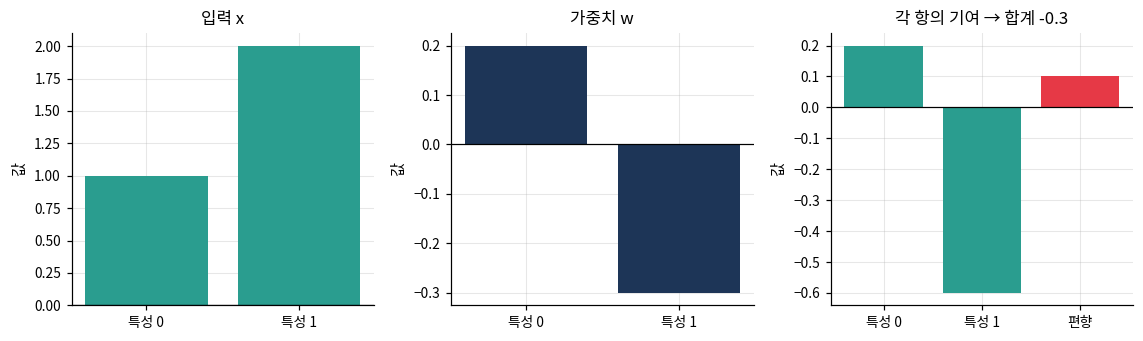

In [6]:
plot_weighted_sum(x, w, contributions, bias, z_vector)

첫 입력은 출력에 $+0.2$, 두 번째 입력은 $-0.6$, 편향은 $+0.1$만큼 기여합니다.
`*`는 위치별 값을 남기고, `@`는 여기서 특성 축을 더해 하나로 줄입니다.

**바꿔 보기:** `x[1]`만 3으로 바꾸면 출력은 얼마나 달라질까요?
두 번째 가중치 $-0.3$이 이 입력의 한 단위 변화가 출력에 미치는 영향을 나타냅니다.

In [7]:
x_changed = x.copy()
x_changed[1] = 3.0
change = vector_neuron(x_changed, w, bias) - z_vector
np.testing.assert_allclose(change, -0.3)
print("두 번째 입력을 1 늘렸을 때 출력 변화:", change)

두 번째 입력을 1 늘렸을 때 출력 변화: -0.30000000000000004


## 3. 샘플 여러 개를 행으로 모읍니다

한 번에 계산할 샘플 수를 $N$이라고 하겠습니다. 입력 $X$는 `(N, D)` 행렬입니다.
**행은 샘플, 열은 특성**이라는 규약을 씁니다.

$$z_n=\sum_{d=0}^{D-1}X_{nd}w_d+b,\qquad n=0,\ldots,N-1.$$

남는 인덱스는 샘플 번호 $n$이고, 합으로 사라지는 인덱스는 특성 번호 $d$입니다.
코드로 옮기기 전에 “어떤 축을 더하고 어떤 축을 남기는가?”를 묻는 습관을 들입니다.

| 기호 | 모양 | 의미 |
|---|---|---|
| $X$ | `(N, D)` | $N$개 샘플의 $D$개 특성 |
| $w$ | `(D,)` | 모든 샘플에 공통으로 쓸 가중치 |
| $b$ | 스칼라 | 모든 샘플에 더할 편향 |
| $z$ | `(N,)` | 샘플마다 하나의 출력 |

In [8]:
def batch_neuron_loop(X, w, bias):
    output = np.empty(len(X))
    for n in range(len(X)):
        output[n] = dot_loop(X[n], w) + bias
    return output

In [9]:
X = np.array([[1.0, 2.0], [3.0, -1.0], [-2.0, 1.0]])
z_batch_loop = batch_neuron_loop(X, w, bias)
z_batch = X @ w + bias
expected = np.array([-0.3, 1.0, -0.6])
np.testing.assert_allclose(z_batch_loop, expected)
np.testing.assert_allclose(z_batch, expected)
print("X.shape", X.shape, "→ z.shape", z_batch.shape)
print("출력", z_batch)

X.shape (3, 2) → z.shape (3,)
출력 [-0.3  1.  -0.6]


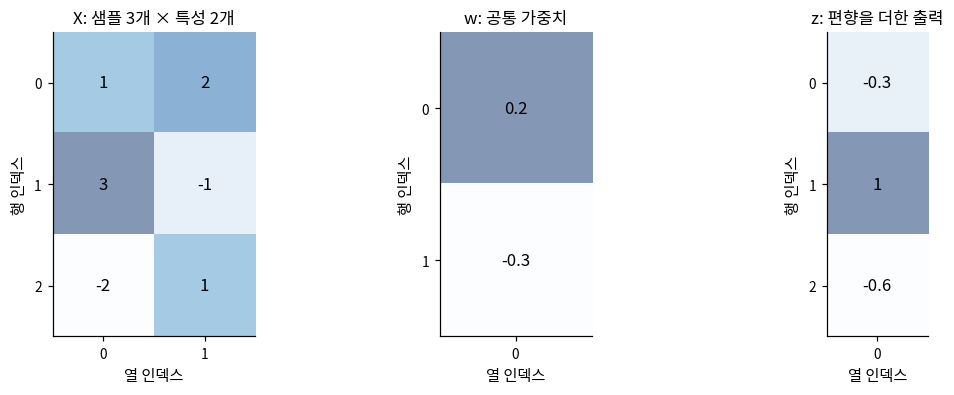

In [10]:
plot_product(X, w, z_batch,
             ["X: 샘플 3개 × 특성 2개", "w: 공통 가중치", "z: 편향을 더한 출력"])

행마다 같은 $w$와 $b$를 사용했습니다. 행을 늘려도 파라미터 개수는 그대로입니다.
`X @ w`는 샘플별 내적을 한 번에 계산합니다. 반복문을 배열 연산으로 표현한 것이 **벡터화(vectorization)**입니다.

출력 하나를 일부러 열벡터 `(N, 1)`로 유지하려면 가중치도 `(D, 1)`로 두면 됩니다.

In [11]:
w_column = w[:, None]     # None이 길이 1인 새 축을 만듭니다.
z_column = X @ w_column + bias
assert w_column.shape == (2, 1) and z_column.shape == (3, 1)
np.testing.assert_allclose(z_column[:, 0], z_batch)
print("열벡터로 유지한 출력:\n", z_column)

열벡터로 유지한 출력:
 [[-0.3]
 [ 1. ]
 [-0.6]]


## 4. 출력도 여러 개로 늘립니다

출력 개수를 $K$라고 쓰고, 각 출력이 자기 가중치를 갖게 하겠습니다.
$W$의 **열 하나가 출력 하나에 쓰이는 가중치 벡터**입니다.

$$Z_{nk}=\sum_{d=0}^{D-1}X_{nd}W_{dk}+b_k,$$

$$\underbrace{Z}_{(N,K)}=\underbrace{X}_{(N,D)}\underbrace{W}_{(D,K)}+\underbrace{b}_{(K,)}.$$

곱하는 두 행렬의 안쪽 차원 $D$가 같아야 합니다. 합을 계산한 뒤에는 바깥쪽 차원 `(N, K)`가 남습니다.
수학에서 편향을 더한 이런 계산을 **아핀 변환(affine transformation)**이라고 부릅니다.
신경망에서는 이 부분을 흔히 선형층이라고 부릅니다.

In [12]:
def affine_loop(X, W, b):
    N, D = X.shape
    K = W.shape[1]
    Z = np.empty((N, K))
    for n in range(N):
        for k in range(K):
            Z[n, k] = b[k]
            for d in range(D):
                Z[n, k] += X[n, d] * W[d, k]
    return Z


def affine(X, W, b):
    if X.ndim != 2 or W.ndim != 2 or b.shape != (W.shape[1],):
        raise ValueError("X는 (N,D), W는 (D,K), b는 (K,)로 둡니다.")
    if X.shape[1] != W.shape[0]:
        raise ValueError("X의 특성 수와 W의 입력 수가 같아야 합니다.")
    return X @ W + b

In [13]:
W = np.array([[0.2, 1.0], [-0.3, 0.5]])
b = np.array([0.1, -0.2])
Z_loop = affine_loop(X, W, b)
Z = affine(X, W, b)
expected_Z = np.array([[-0.3, 1.8], [1.0, 2.3], [-0.6, -1.7]])
np.testing.assert_allclose(Z_loop, expected_Z)
np.testing.assert_allclose(Z, expected_Z)
print("X", X.shape, "@ W", W.shape, "+ b", b.shape, "→ Z", Z.shape)
print(Z)

X (3, 2) @ W (2, 2) + b (2,) → Z (3, 2)
[[-0.3  1.8]
 [ 1.   2.3]
 [-0.6 -1.7]]


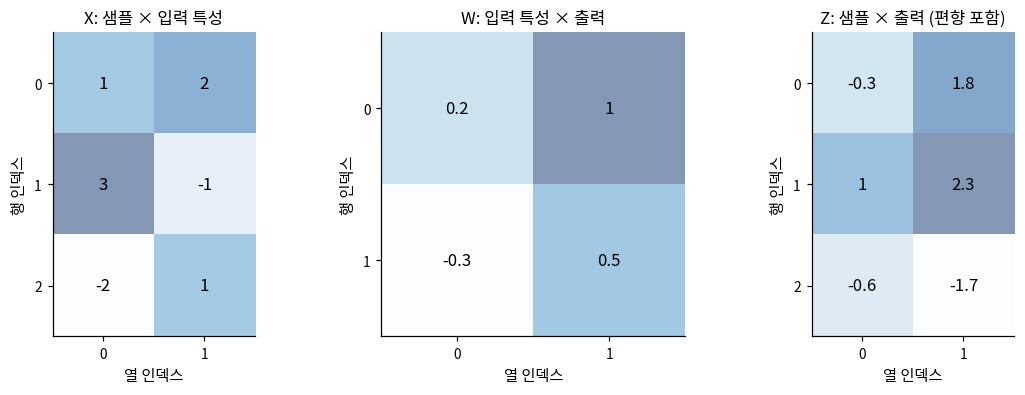

In [14]:
plot_product(X, W, Z,
             ["X: 샘플 × 입력 특성", "W: 입력 특성 × 출력", "Z: 샘플 × 출력 (편향 포함)"])

반복문에서는 `n`, `k`, `d` 세 인덱스를 썼지만, 행렬곱은 그중 `d`를 합하는 규칙을 담고 있습니다.
CNN에서는 이 입력을 작은 이미지 패치로 바꾸고 같은 가중치를 위치마다 공유합니다.
Attention에서도 먼저 이런 행렬곱으로 입력을 다른 표현으로 바꿉니다.
뒤의 구조를 공부할 때 이 한 줄을 다시 만나게 됩니다.

## 5. 축과 브로드캐스팅을 확인합니다

`X @ W`는 `(N, K)`인데 `b`는 `(K,)`입니다.
NumPy는 뒤쪽 축부터 길이를 맞추고, 길이 1인 축은 반복해서 쓰는 것처럼 계산합니다.
이 규칙이 **브로드캐스팅(broadcasting)**입니다.

여기서는 편향을 샘플마다 공통으로 더합니다. 같은 값을 여러 샘플에 쓰는 관계가
다음 노트북의 편향 기울기에서 **샘플 축의 합**으로 돌아옵니다.

`sum(axis=0)`은 행 방향으로 샘플들을 합쳐 `(K,)`를 남기고,
`sum(axis=1)`은 열 방향으로 출력들을 합쳐 `(N,)`을 남깁니다.

In [15]:
bias_rows = np.broadcast_to(b, Z.shape)
np.testing.assert_allclose(X @ W + bias_rows, Z)
np.testing.assert_allclose(Z.sum(axis=0), [0.1, 2.4])
np.testing.assert_allclose(Z.sum(axis=1), [1.5, 3.3, -2.3])
print("샘플마다 적용되는 편향:\n", bias_rows)
print("axis=0: 샘플을 합함", Z.sum(axis=0))
print("axis=1: 출력을 합함", Z.sum(axis=1))
print("keepdims=True로 축을 남김", Z.sum(axis=0, keepdims=True).shape)

샘플마다 적용되는 편향:
 [[ 0.1 -0.2]
 [ 0.1 -0.2]
 [ 0.1 -0.2]]
axis=0: 샘플을 합함 [0.1 2.4]
axis=1: 출력을 합함 [ 1.5  3.3 -2.3]
keepdims=True로 축을 남김 (1, 2)


### 모양이 맞아도 의미가 다를 수 있습니다

샘플 2개에 대해 각각 $+10$, $+20$을 더하려고 한다고 해 보겠습니다.
출력 개수도 2개이면 `(2,)`는 출력 축에 맞추어집니다.
샘플별 값을 더하려면 `(2, 1)`로 샘플 축을 명시합니다.

In [16]:
base = np.array([[1.0, 2.0], [3.0, 4.0]])
per_sample = np.array([10.0, 20.0])
by_output = base + per_sample
by_sample = base + per_sample[:, None]
np.testing.assert_array_equal(by_output, [[11.0, 22.0], [13.0, 24.0]])
np.testing.assert_array_equal(by_sample, [[11.0, 12.0], [23.0, 24.0]])
assert not np.array_equal(by_output, by_sample)
print("(2,)를 더했을 때:\n", by_output)
print("(2,1)을 더했을 때:\n", by_sample)

(2,)를 더했을 때:
 [[11. 22.]
 [13. 24.]]
(2,1)을 더했을 때:
 [[11. 12.]
 [23. 24.]]


숫자의 크기가 우연히 같으면 실행 오류가 생기지 않아도 의도와 다른 축으로 계산할 수 있습니다.
따라서 shape 옆에 **샘플·특성·출력이라는 의미**도 적습니다.

## 6. reshape와 transpose는 다른 일을 합니다

`reshape`는 원소를 읽는 순서를 유지하면서 모양을 다시 잡습니다.
`transpose`는 축을 교환합니다. 2차원 배열의 `.T`는 행과 열을 바꿉니다.

원소 수가 같다는 것만으로 수학적으로 같은 배열이 되지는 않습니다.
아래 세 배열에서 숫자 1의 위치를 먼저 예상해 보세요.

In [17]:
original = np.arange(6).reshape(2, 3)
transposed = original.T
reshaped = original.reshape(3, 2)
np.testing.assert_array_equal(transposed, [[0, 3], [1, 4], [2, 5]])
np.testing.assert_array_equal(reshaped, [[0, 1], [2, 3], [4, 5]])
assert not np.array_equal(transposed, reshaped)
print("원본:\n", original)
print("transpose:\n", transposed)
print("reshape:\n", reshaped)

원본:
 [[0 1 2]
 [3 4 5]]
transpose:
 [[0 3]
 [1 4]
 [2 5]]
reshape:
 [[0 1]
 [2 3]
 [4 5]]


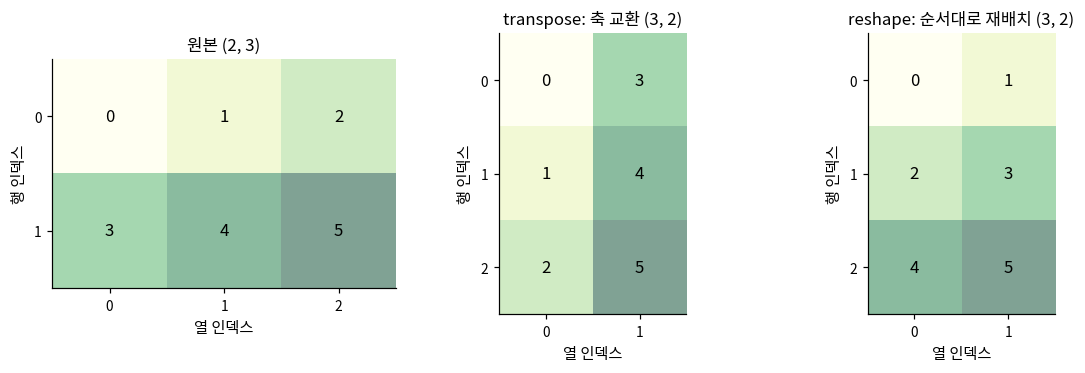

In [18]:
plot_layout(original, transposed, reshaped)

행과 열의 의미를 교환하려면 transpose를 씁니다.
기울기 식에 $X^\top$가 나타나면 `X.T`로 옮기는 이유입니다.
reshape가 필요한 경우에는 어느 축의 원소들이 어떤 순서로 묶이는지 따로 확인합니다.

## 7. 같은 계산을 그림으로 봅니다

두 입력에 대한 출력 $z=0.2x_0-0.3x_1+0.1$은 평면입니다.
입력 좌표를 움직이면 가중치가 정한 기울기로 출력이 변합니다.

격자 좌표와 예측값은 아래에서 직접 계산합니다. 그림 함수는 이 계산 결과를 그립니다.

좌표를 평면 그림의 입력으로 바꾸는 과정도 배열 연산입니다.

| 연산 | 의미 | 이 예제의 shape |
|---|---|---|
| `np.linspace(-3, 3, 35)` | -3부터 3까지 같은 간격의 숫자 35개 만들기 | `(35,)` |
| `np.meshgrid(x좌표, y좌표)` | 가능한 모든 좌표 쌍을 두 격자로 펼치기 | `xx`, `yy` 각각 `(35, 35)` |
| `xx.ravel()`, `yy.ravel()` | 각 격자를 같은 순서로 한 줄에 펴기 | 각각 `(1225,)` |
| `np.column_stack([...])` | 두 좌표 목록을 열로 나란히 붙이기 | `points`: `(1225, 2)` |
| `points @ w + bias` | 좌표 한 쌍을 샘플 한 개로 보고 출력 계산하기 | `(1225,)` |
| `.reshape(xx.shape)` | 출력 1225개를 원래 격자 위치에 놓기 | `zz`: `(35, 35)` |

`xx[i, j]`와 `yy[i, j]`가 한 점의 두 좌표입니다. 격자의 행은 $x_1$, 열은 $x_0$의 위치를 나타냅니다.


In [19]:
xx, yy = np.meshgrid(np.linspace(-3, 3, 35), np.linspace(-3, 3, 35))
points = np.column_stack([xx.ravel(), yy.ravel()])
zz = (points @ w + bias).reshape(xx.shape)
np.testing.assert_allclose(zz, 0.2 * xx - 0.3 * yy + 0.1)

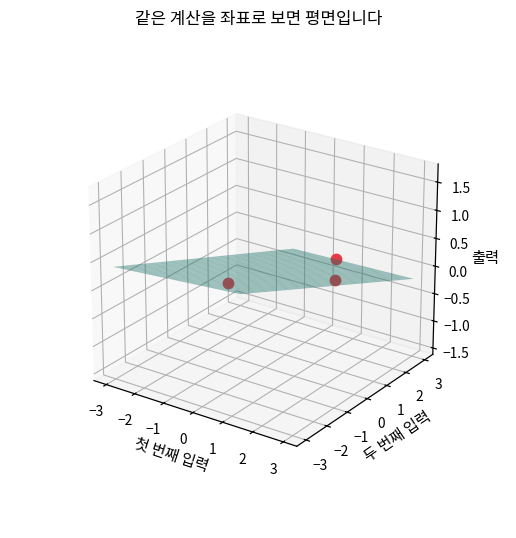

In [20]:
plot_affine_plane(xx, yy, zz, X, z_batch)

평면의 방향은 가중치가, 전체 높이는 편향이 결정합니다.
다음 노트북에서는 관측된 정답에 맞추어 이 방향과 높이를 갱신합니다.

## 8. 직접 바꿔서 확인합니다

### 연습 A · 출력 3개를 만들기

다음 입력으로 출력 `(2, 3)`을 계산해 보세요.
먼저 첫 샘플의 세 출력을 손으로 구하고 실행합니다.
직접 작성한 함수를 검사할 때는 아래 호출의 `affine`을 그 함수 이름으로 바꿉니다.

검사 함수에 들어 있는 값들은 고정된 작은 문제의 손계산 정답입니다.

검사 예제 셀 아래에 새 Code 셀을 만들고 `my_affine(X, W, b)`를 직접 정의해 실행하세요. 그다음 셀에서 `check_three_outputs(my_affine)`을 실행합니다. 함수 이름을 전달할 때는 `my_affine()`처럼 괄호를 붙이지 않습니다.

In [21]:
def check_three_outputs(candidate):
    example_X = np.array([[1., 2.], [-1., 3.]])
    example_W = np.array([[1., 0., -2.], [0.5, 2., 1.]])
    example_b = np.array([0., 1., -1.])
    actual = candidate(example_X, example_W, example_b)
    assert actual.shape == (2, 3)
    np.testing.assert_allclose(actual, [[2., 5., -1.], [0.5, 7., 4.]])
    print("출력 3개: 손계산과 일치합니다.")

In [22]:
check_three_outputs(affine)

출력 3개: 손계산과 일치합니다.


### 연습 B · 가중치 하나를 바꾸면 어떤 출력이 바뀔까요?

$W_{dk}$는 특성 $d$에서 출력 $k$로 연결됩니다.
`W[0, 1]`만 0.5 늘리면, 각 샘플에서 두 번째 출력이 입력의 첫 번째 값에 비례해 변합니다.
아래 기대 변화량을 보고 이유를 설명한 뒤 실행합니다.

In [23]:
W_changed = W.copy()
W_changed[0, 1] += 0.5
Z_changed = affine(X, W_changed, b)
expected_change = np.array([[0., 0.5], [0., 1.5], [0., -1.]])
np.testing.assert_allclose(Z_changed - Z, expected_change)
print("출력의 변화:\n", Z_changed - Z)

출력의 변화:
 [[ 0.   0.5]
 [ 0.   1.5]
 [ 0.  -1. ]]


### 연습 C · 다음 노트북으로 갈 준비

예제 셀을 가리고 다음을 설명하거나 작성해 보세요.

1. 입력 `(5, 4)`, 가중치 `(4, 3)`, 편향 `(3,)`의 출력 모양을 정할 수 있나요?
2. $Z_{nk}=\sum_d X_{nd}W_{dk}+b_k$에서 합하는 축과 남는 축을 말할 수 있나요?
3. 샘플별 값을 더할 때와 출력별 값을 더할 때 배열 모양을 다르게 정할 수 있나요?
4. 4절의 반복문과 벡터화 함수를 직접 다시 작성할 수 있나요?

막힌 항목에 해당하는 절을 다시 보고, 숫자나 차원을 바꿔 한 번 더 검산합니다.

**다음:** [01 · 미분으로 학습시키기](01_gradients_and_learning.ipynb).
지금 계산한 출력의 오차를 이용해 $W$와 $b$를 어떻게 바꿀지 직접 유도합니다.